#### Scaling/Normalization, Detrend

MinMaxScaler, StandardScaler, RobustScaler (quantile, not sensitive to outliers), Normalizer (unit norm)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# df = pd.read_csv('airline-passengers.csv')
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')

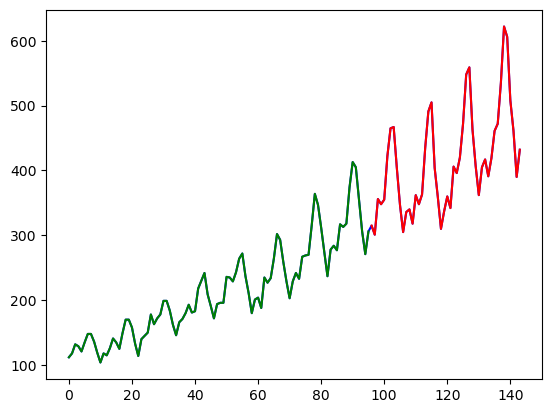

In [9]:
from sklearn.preprocessing import MinMaxScaler

train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train_raw, test_raw = timeseries[:train_size], timeseries[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)
train = scaler.transform(train_raw)
test = scaler.transform(test_raw)

# after training
train_plot = scaler.inverse_transform(train)
test_plot = scaler.inverse_transform(test)

# check the inversed data with original data
plt.plot(timeseries, c='b')
plt.plot(train_plot, c='g')
plt.plot(range(train_size, len(timeseries)), test_plot, c='r')

# CANNOT use fit_transform on the whole dataset
# this will transform the trained data with test data information
# timeseries_norm = scaler.fit_transform(timeseries)


In [ ]:
from sklearn.preprocessing import StandardScaler
# 转为均值0 方差1

scaler = StandardScaler()
timeseries_norm = scaler.fit_transform(timeseries)


In [26]:
from sklearn.preprocessing import RobustScaler

X = [[ 1., -2.,  2.],
     [ -2.,  1.,  3.],
     [ 4.,  1., -2.]]
scaler = RobustScaler()
scaler.fit(X)
print(scaler.get_params())
print(scaler.transform(X)) 
# 按行scale，如 1,-2,4 视为一组, 减去的是各行的median
# 减完再除以 IQR=Q3-Q1 = 75% quantile-25% quantile

np.percentile(X, (25, 50, 75), axis=0)

{'copy': True, 'quantile_range': (25.0, 75.0), 'unit_variance': False, 'with_centering': True, 'with_scaling': True}
[[ 0.  -2.   0. ]
 [-1.   0.   0.4]
 [ 1.   0.  -1.6]]


array([[-0.5, -0.5,  0. ],
       [ 1. ,  1. ,  2. ],
       [ 2.5,  1. ,  2.5]])

In [39]:
from sklearn.preprocessing import Normalizer, normalize

X = [[4, 1, 2, 2],
     [1, 3, 9, 3],
     [5, 7, 5, 1]]
scaler = Normalizer()
scaler.fit(X)
X_norm = scaler.transform(X)
print(X_norm)
# 每个样本归一化到单位长度 
# Normalize samples individually to unit norm (vector length)

X_norm[:,0] # 如何求norm？

[[0.8 0.2 0.4 0.4]
 [0.1 0.3 0.9 0.3]
 [0.5 0.7 0.5 0.1]]


array([0.8, 0.1, 0.5])

In [4]:
from scipy import signal

detrended = signal.detrend(timeseries)
# 直接用detrend是不可逆的；如果要可逆，需要自己拟合趋势，最后再把减掉的趋势加回来

# 机器学习 / 深度学习中，detrend 不常用，因为它能自己学习拟合趋势，如果 detrend，可能反而让模型失去信息
# 趋势本身是重要信息（比如客运量逐年上升）。
# 如果你把趋势去掉：
# → LSTM 只能学到周期性，但预测长期趋势会不准确
# → 预测可能变成“震荡，但不往上”

(144, 1)

#### train/test in sklearn

- model selection: https://scikit-learn.org/stable/api/sklearn.model_selection.html
- metrics: https://scikit-learn.org/stable/api/sklearn.metrics.html

In [ ]:
from sklearn.model_selection import train_test_split

X = np.arange(10).reshape((5, 2)) 
y = range(5) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, shuffle=False)
# 这个 shuffle 会把样本顺序打乱（这里5是样本数），时序预测须关闭 


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
# Provides train/test indices to split time-ordered data

# 其实手动写也可以了，不是很需要用函数
train_size = int(len(series) * 0.67)
train = series[:train_size]
test = series[train_size:]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
#  特征变换
# PolynomialFeatures
# OneHotEncoder
# LabelEncoder

In [ ]:
#  sklearn:
# LinearRegression
# LogisticRegression
# RandomForestClassifier / Regressor
# SVM
# KMeans
# PCA

#### Loss function, L2/L1 regularization

In [75]:
import torch
import torch.nn as nn

In [ ]:
loss_fn = nn.MSELoss()
loss = loss_fn(pred, target)

loss_fn = nn.L1Loss()

loss_fn = nn.BCEWithLogitsLoss()

loss_fn = nn.CrossEntropyLoss()


给特定某一层、特定weights加正则：
1. 通过 optimizer 的 param_groups 指定不同正则强度。 2. 手动添加。 

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# L2 penalty = 1e-4
# 自动加在所有参数上（但不包括 bias 和 LayerNorm/BatchNorm (?)）

# 只给某一层
optimizer = torch.optim.Adam([
    {'params': model.fc.parameters(), 'weight_decay': 1e-4},
    {'params': model.conv.parameters(), 'weight_decay': 0.0}
])

In [ ]:
l1_lambda = 1e-4
l1_norm = 0
# bias一般不作正则化
for name, p in model.named_parameters():
    if "bias" not in name:
        l1_norm += p.abs().sum()
# l1_norm = sum(p.abs().sum() for p in model.parameters())

# 只给某层加正则
l1_reg = 0
for p, name in model.linear.parameters():
    l1_reg += torch.sum(torch.abs(p))

# 只给某个变量
l2_reg = 0
for name, p in model.named_parameters():
    if 'weight_hh' in name:
        l2_reg += torch.sum(p**2)

loss = data_loss + l1_lambda * l1_norm
loss.backward()


In [84]:
class M(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Linear(3,4)
        self.lstm = nn.LSTM(4, 5)
        self.dec = nn.Linear(5, 1)

model = M()

# 只取 encoder 的参数
print(list(model.enc.named_parameters()))

# 只取 LSTM 的参数
# print(list(model.lstm.named_parameters()))
print(dict(model.lstm.named_parameters()).keys())

# 所有参数
print(len(list(model.parameters())))


[('weight', Parameter containing:
tensor([[ 0.4379,  0.1532, -0.1029],
        [-0.1236, -0.0875,  0.5147],
        [-0.4947,  0.3257, -0.2068],
        [-0.3019,  0.2297, -0.5006]], requires_grad=True)), ('bias', Parameter containing:
tensor([0.3212, 0.2135, 0.2922, 0.3209], requires_grad=True))]
dict_keys(['weight_ih_l0', 'weight_hh_l0', 'bias_ih_l0', 'bias_hh_l0'])
8


#### how to change initilization before training?
![Alt text](image-2.png)

In [ ]:
def init_lstm_weights(model):
    if isinstance(model, nn.LSTM):
        for name, param in model.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

model = MyModel()
model.apply(init_lstm_weights)  # 会递归地访问 model 内所有 modules


weight_hh_l0.shape = (4*hidden_size, hidden_size)  # LSTM

weight_hh_l0.shape = (hidden_size, hidden_size)    # RNN-tanh/RNN-relu

weight_hh_l0.shape = (3*hidden_size, hidden_size)  # GRU


In [ ]:
def init_recurrent_weights(m, g=1.0):
    if isinstance(m, (nn.RNN, nn.LSTM, nn.GRU)):
        for name, param in m.named_parameters():
            if "weight_hh" in name:
                hidden_size = param.shape[1]  # N
                std = g / (hidden_size ** 0.5)
                nn.init.normal_(param, mean=0.0, std=std)


#### Scipy
scipy.stats, scipy.optimize

scipy.stats 的重点不是基础统计，而是 概率分布、统计检验、随机变量抽样， \
np.mean, np.std, … 用np更快、更简洁

In [ ]:
# from scipy.optimize import minimize, curve_fit, least_squares
from scipy import optimize

optimize.minimize()
optimize.curve_fit()


In [ ]:
from scipy import linalg

linalg.svd()
linalg.eig()
linalg.solve()

# 还可以生成稀疏矩阵


In [47]:
from scipy import stats

X = np.array([[ 1., -2.,  2.],
     [ -2.,  1.,  3.],
     [ 4.,  1., -2.]])

# 基础统计
x = X.flatten()
np.mean(x)
np.std(x)
np.var(x)
np.median(x)
np.percentile(x, 95)

np.linalg.norm(x)
np.linalg.solve(A, b)
np.linalg.inv(A) 
np.linalg.pinv(A) #求 Moore–Penrose 伪逆
np.linalg.eig(A)
np.linalg.svd(A, full_matrices=True)
np.linalg.det(A)
np.linalg.matrix_rank(A)


# Compute several descriptive statistics of the passed array.
stats.describe(X.flatten()) 


DescribeResult(nobs=9, minmax=(-2.0, 4.0), mean=0.6666666666666666, variance=5.0, skewness=-0.05533985905294653, kurtosis=-1.2675000000000003)

In [ ]:
from scipy import stats

# scipy适合用来处理 概率分布，都支持统一API：pdf, cdf, ppf, rvs, mean, var
from scipy.stats import norm, poisson, uniform, expon, binom

norm.pdf(x, loc, scale)
norm.cdf(x, loc, scale)
norm.ppf(x, loc, scale) # 分位数
norm.rvs(loc, scale, size=100) # 采样

# scipy还适合处理 假设检验



#### How to set dropout for training?

#### 对象的属性attribute xx.yy /方法 method xx.yy()

区分一个名字是方法还是属性，print(x.yy)：
- 如果显示 <bound method ...> → 它是方法，需要括号
- 如果显示某个值（数字、shape、tensor 等）→ 它是属性，不需要括号
- type(x.yy)也会显示这是一个function/method（需要括号），还是int/tuple/tensor/dtype/bool

In [65]:
import numpy as np
a = np.array([1,2,3])

# 查看文档 help(xx)

help(np.reshape)
help(a.reshape)


Help on function reshape in module numpy:

reshape(a, newshape, order='C')
    Gives a new shape to an array without changing its data.
    
    Parameters
    ----------
    a : array_like
        Array to be reshaped.
    newshape : int or tuple of ints
        The new shape should be compatible with the original shape. If
        an integer, then the result will be a 1-D array of that length.
        One shape dimension can be -1. In this case, the value is
        inferred from the length of the array and remaining dimensions.
    order : {'C', 'F', 'A'}, optional
        Read the elements of `a` using this index order, and place the
        elements into the reshaped array using this index order.  'C'
        means to read / write the elements using C-like index order,
        with the last axis index changing fastest, back to the first
        axis index changing slowest. 'F' means to read / write the
        elements using Fortran-like index order, with the first index
        c

In [73]:
# 列出全部属性和方法
dir(a)
print(dir(a)[120:125])

# 寻找方法/属性
# 1. 搜索
print([m for m in dir(a) if 'mean' in m.lower()])
# 2. 用自动补全
# 3. help(xx)

# type(xx)知道对象是哪个class，然后查class文档
type(a)
# help(np.ndarray)

['flags', 'flat', 'flatten', 'getfield', 'imag']
['mean']


numpy.ndarray

In [64]:
# xx.__dict__（只显示可写属性）
# 许多 Python 对象把属性放在 __dict__ 字典里。

class A:
    def __init__(self):
        self.x = 1
        self.y = 2

object = A()
print(object.__dict__)


{'x': 1, 'y': 2}


In [ ]:
a.ndim          # 属性：维度
a.shape         # 属性：形状
a.dtype         # 属性：数据类型

a.sum()         # 方法：求和
a.mean()        # 方法：求均值
a.reshape()     # 方法：变化形状

numpy
| 属性             | 含义      | 示例                 |
| -------------- | ------- | ------------------ |
| `arr.shape`    | 数组形状    | `(100, 3)`         |
| `arr.ndim`     | 数组维度    | `2`                |
| `arr.size`     | 元素总数    | `300`              |
| `arr.dtype`    | 数据类型    | `dtype('float32')` |
| `arr.itemsize` | 单个元素字节数 | `4`                |
| `arr.nbytes`   | 总字节数    | `1200`             |
| `arr.T`        | 转置      | `(3,100)`          |
| `arr.real`     | 实部      |                    |
| `arr.imag`     | 虚部      |                    |
| `arr.flags`    | 内存信息    | seldom used        |


| 方法                              | 作用     |
| ------------------------------- | ------ |
| `arr.reshape(newshape)`         | 改变形状   |
| `arr.flatten()`                 | 展平成 1D |
| `arr.transpose()`               | 转置     |
| `np.concatenate([a,b], axis=0)` | 拼接     |
| `np.stack([a,b], axis=0)`       | 创建新维度  |
| `np.split(arr, n, axis=0)`      | 拆分     |


| 方法                  | 作用 |
| ------------------- | -- |
| `arr.sum(axis=…)`   |    |
| `arr.mean(axis=…)`  |    |
| `arr.std(axis=…)`   |    |
| `arr.min(axis=…)`   |    |
| `arr.max(axis=…)`   |    |
| `np.dot(a,b)`       | 点积 |
| `np.exp(arr)`       |    |
| `np.log(arr + eps)` |    |


| 方法                    | 作用 |
| --------------------- | -- |
| `np.where(condition)` |    |
| `np.argmin()`         |    |
| `np.argmax()`         |    |


pytorch
| 属性                               | 含义         |
| -------------------------------- | ---------- |
| `x.shape` / `x.size()`（size 是方法） | 张量形状       |
| `x.ndim`                         | 维度         |
| `x.dtype`                        | 数据类型       |
| `x.device`                       | CPU or GPU |
| `x.requires_grad`                | 是否需要梯度     |
| `x.grad`                         | 梯度值（训练后）   |
| `x.T`                            | 转置（2D 时）   |

| 方法                        | 作用                |
| ------------------------- | ----------------- |
| `x.view(newshape)`        | reshape（严格要求连续内存） |
| `x.reshape(newshape)`     | 更安全，推荐            |
| `x.squeeze(dim)`          | 去掉维度=1            |
| `x.unsqueeze(dim)`        | 增加维度              |
| `torch.stack([...], dim)` |                   |
| `torch.cat([...], dim)`   |                   |


| 方法             | 含义   |
| -------------- | ---- |
| `x.mean(dim)`  |      |
| `x.sum(dim)`   |      |
| `x.max(dim)`   |      |
| `x.min(dim)`   |      |
| `torch.exp(x)` |      |
| `torch.log(x)` |      |
| `x.matmul(y)`  | 矩阵乘法 |
| `x.dot(y)`     | 向量点积 |

| 方法/属性                  | 含义         |
| ---------------------- | ---------- |
| `x.backward()`         | 反向传播       |
| `x.detach()`           | 切断梯度       |
| `x.clone()`            | 深拷贝        |
| `x.to(device)`         | 移到 GPU/CPU |
| `x.float()` `x.long()` | 类型转换       |


| 方法                    | 作用 |
| --------------------- | -- |
| `torch.manual_seed()` |    |
| `torch.randn()`       |    |
| `torch.rand()`        |    |
| `torch.randint()`     |    |





In [67]:
import torch

t = torch.tensor(a)

t.requires_grad    # 属性
t.shape            # 属性

t.detach()         # 方法
t.numpy()          # 方法
t[0].item()           # 方法


1

In [ ]:
scaler.data_min_   # 属性（训练好的参数）
scaler.data_max_   # 属性

scaler.fit()       # 方法
scaler.transform() # 方法
scaler.fit_transform() # 方法
